# Analogical reasoning between diseases

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scanpy as sc

import os, sys, time, json
sys.path.append('../../')
from polygene.model.model import load_trained_model
from polygene.data_utils.tokenization import normalise_str

model_directory = '/media/lleger/LaCie/mit/runs/polygene_tied_linear_reconstruct/'
model, tokenizer = load_trained_model(model_directory)
embedding_matrix = model.embeddings.token_value_embeddings.weight.detach().cpu().numpy()

frequent_diseases.remove('[arrhythmogenic_right_ventricular_cardiomyopathy]')
frequent_diseases.remove('[gastritis]')
frequent_diseases.remove('[post_covid_19_disorder]')
frequent_diseases = [normalise_str(d) for d in json.load(open('/media/lleger/LaCie/mit/disease_geometry/diseases.json'))['diseases']]
disease_indices_in_embedding_matrix = [tokenizer.token_to_id_map[d] for d in frequent_diseases]

disease_embeddings = embedding_matrix[disease_indices_in_embedding_matrix]
from sklearn.decomposition import PCA

pca = PCA(n_components=5, )
pca.fit(disease_embeddings)
#cumulative_variance = pca.explained_variance_ratio_.cumsum()
#number_of_components = np.argmax(cumulative_variance >= 0.90 ) + 1
#print(number_of_components)
disease_embeddings_reduced = pca.transform(disease_embeddings)#[:, :number_of_components]

disease_transformations = (disease_embeddings[None, :] - disease_embeddings[:, None])
disease_transformations = (disease_embeddings_reduced[None, :] - disease_embeddings_reduced[:, None])

In [73]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

number_of_diseases = disease_transformations.shape[0]
embedding_dimension = disease_transformations.shape[2]

flattened_transformations = disease_transformations.reshape(number_of_diseases * number_of_diseases, embedding_dimension)

cosine_similarity_matrix = cosine_similarity(flattened_transformations)

upper_triangle_row_indices, upper_triangle_column_indices = np.triu_indices(number_of_diseases * number_of_diseases, k=0)

disease_a_indices = upper_triangle_row_indices // number_of_diseases
disease_b_indices = upper_triangle_row_indices % number_of_diseases
disease_c_indices = upper_triangle_column_indices // number_of_diseases
disease_d_indices = upper_triangle_column_indices % number_of_diseases

disease_a_names = np.array(frequent_diseases)[disease_a_indices]
disease_b_names = np.array(frequent_diseases)[disease_b_indices]
disease_c_names = np.array(frequent_diseases)[disease_c_indices]
disease_d_names = np.array(frequent_diseases)[disease_d_indices]

similarity_values = cosine_similarity_matrix[upper_triangle_row_indices, upper_triangle_column_indices]

mask = (
    (disease_a_indices != disease_b_indices) & 
    (disease_a_indices != disease_c_indices) & 
    (disease_a_indices != disease_d_indices) & 
    (disease_b_indices != disease_c_indices) & 
    (disease_b_indices != disease_d_indices) & 
    (disease_c_indices != disease_d_indices)
)

analogy_similarity_dataframe = pd.DataFrame({
    'disease_a': np.array(frequent_diseases)[disease_a_indices[mask]],
    'disease_b': np.array(frequent_diseases)[disease_b_indices[mask]],
    'disease_c': np.array(frequent_diseases)[disease_c_indices[mask]],
    'disease_d': np.array(frequent_diseases)[disease_d_indices[mask]],
    'cosine_similarity': similarity_values[mask]
})

In [74]:
disease_analogy = analogy_similarity_dataframe[(analogy_similarity_dataframe['cosine_similarity'] != 0) & (np.abs(analogy_similarity_dataframe['cosine_similarity']) < 0.99)]
disease_analogy['cosine_similarity'] = np.abs(disease_analogy['cosine_similarity'])
disease_analogy.drop_duplicates(subset=['disease_a', 'disease_b', 'disease_c', 'disease_d'], inplace=True)
disease_analogy.sort_values('cosine_similarity', ascending=False, inplace=True)
disease_analogy['canonical_key'] = disease_analogy.apply(
    lambda row: tuple(sorted([
        tuple(sorted([row['disease_a'], row['disease_b']])),
        tuple(sorted([row['disease_c'], row['disease_d']]))
    ])), axis=1
)
disease_analogy = disease_analogy.drop_duplicates(subset='canonical_key').drop(columns='canonical_key')
print(disease_analogy.shape)
n = 50
display(disease_analogy.head(50), disease_analogy.tail(50))

/tmp/ipykernel_1771847/2868166023.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disease_analogy['cosine_similarity'] = np.abs(disease_analogy['cosine_similarity'])
/tmp/ipykernel_1771847/2868166023.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disease_analogy.drop_duplicates(subset=['disease_a', 'disease_b', 'disease_c', 'disease_d'], inplace=True)
/tmp/ipykernel_1771847/2868166023.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

(535013, 5)


,disease_a,disease_b,disease_c,disease_d,cosine_similarity
396721,[lung_adenocarcinoma],[small_cell_lung_carcinoma],[plasma_cell_myeloma],[myocardial_infarction],0.989835
553168,[dilated_cardiomyopathy],[b_cell_non_hodgkin_lymphoma],[squamous_cell_lung_carcinoma],[normal],0.989814
1532066,[parkinson_disease],[benign_prostatic_hyperplasia],[common_variable_immunodeficiency],[gastric_intestinal_metaplasia],0.989780
1519230,[parkinson_disease],[blastoma],[periodontitis],[alzheimer_disease],0.989773
2023097,[crohn_ileitis],[interstitial_lung_disease],[trisomy_18],[parkinson_disease],0.989579
2066291,[pulmonary_emphysema],[chronic_obstructive_pulmonary_disease],[chronic_rhinitis],[crohn_disease],0.989456
1738291,[pulmonary_fibrosis],[chronic_kidney_disease],[chronic_rhinitis],[periodontitis],0.989454
555243,[dilated_cardiomyopathy],[plasma_cell_myeloma],[follicular_lymphoma],[clear_cell_renal_carcinoma],0.989291
612926,[crohn_disease],[nonpapillary_renal_cell_carcinoma],[alzheimer_disease],[dilated_cardiomyopathy],0.989268
149406,[covid_19],[gastric_intestinal_metaplasia],[dilated_cardiomyopathy],[digestive_system_disorder],0.989232


,disease_a,disease_b,disease_c,disease_d,cosine_similarity
227786,[glioblastoma],[pulmonary_fibrosis],[crohn_disease],[alzheimer_disease],0.000067
1911104,[gastric_intestinal_metaplasia],[breast_cancer],[type_2_diabetes_mellitus],[clear_cell_renal_carcinoma],0.000066
121181,[covid_19],[acute_kidney_failure],[pulmonary_fibrosis],[dilated_cardiomyopathy],0.000065
946575,[epilepsy],[pneumonia],[periodontitis],[dementia],0.000064
421032,[lung_adenocarcinoma],[chronic_rhinitis],[trisomy_18],[acute_myeloid_leukemia],0.000062
320198,[dementia],[periodontitis],[interstitial_lung_disease],[epilepsy],0.000061
442052,[systemic_lupus_erythematosus],[dementia],[periodontitis],[gastric_intestinal_metaplasia],0.000057
708496,[clear_cell_renal_carcinoma],[b_cell_non_hodgkin_lymphoma],[interstitial_lung_disease],[squamous_cell_lung_carcinoma],0.000056
1913528,[gastric_intestinal_metaplasia],[acute_kidney_failure],[pneumonia],[breast_cancer],0.000055
380976,[lung_adenocarcinoma],[acute_kidney_failure],[crohn_ileitis],[pulmonary_fibrosis],0.000055


(2763600, 5)


,disease_a,disease_b,disease_c,disease_d,cosine_similarity
1547632,[chronic_kidney_disease],[gastritis],[gastric_intestinal_metaplasia],[acute_kidney_failure],0.487266
1622033,[acute_kidney_failure],[gastric_intestinal_metaplasia],[gastritis],[chronic_kidney_disease],0.487266
2468832,[gastritis],[chronic_kidney_disease],[gastric_intestinal_metaplasia],[acute_kidney_failure],0.487266
1546895,[chronic_kidney_disease],[gastritis],[acute_kidney_failure],[gastric_intestinal_metaplasia],0.487266
696084,[dilated_cardiomyopathy],[gastric_intestinal_metaplasia],[gastritis],[arrhythmogenic_right_ventricular_cardiomyopathy],0.463643
2468070,[gastritis],[arrhythmogenic_right_ventricular_cardiomyopathy],[gastric_intestinal_metaplasia],[dilated_cardiomyopathy],0.463643
1472422,[arrhythmogenic_right_ventricular_cardiomyopathy],[gastritis],[gastric_intestinal_metaplasia],[dilated_cardiomyopathy],0.463643
695255,[dilated_cardiomyopathy],[gastric_intestinal_metaplasia],[arrhythmogenic_right_ventricular_cardiomyopathy],[gastritis],0.463643
2348361,[digestive_system_disorder],[arrhythmogenic_right_ventricular_cardiomyopathy],[periodontitis],[dilated_cardiomyopathy],0.454999
689330,[dilated_cardiomyopathy],[periodontitis],[arrhythmogenic_right_ventricular_cardiomyopathy],[digestive_system_disorder],0.454999


,disease_a,disease_b,disease_c,disease_d,cosine_similarity
568263,[systemic_lupus_erythematosus],[myocardial_infarction],[crohn_ileitis],[common_variable_immunodeficiency],1.476514e-06
1722350,[myocardial_infarction],[systemic_lupus_erythematosus],[common_variable_immunodeficiency],[crohn_ileitis],1.476514e-06
577635,[systemic_lupus_erythematosus],[plasma_cell_myeloma],[parkinson_disease],[dilated_cardiomyopathy],1.190033e-06
1918498,[parkinson_disease],[dilated_cardiomyopathy],[plasma_cell_myeloma],[systemic_lupus_erythematosus],1.190033e-06
671917,[dilated_cardiomyopathy],[parkinson_disease],[plasma_cell_myeloma],[systemic_lupus_erythematosus],1.190033e-06
576898,[systemic_lupus_erythematosus],[plasma_cell_myeloma],[dilated_cardiomyopathy],[parkinson_disease],1.190033e-06
1924160,[parkinson_disease],[nonpapillary_renal_cell_carcinoma],[benign_prostatic_hyperplasia],[interstitial_lung_disease],1.075079e-06
1043051,[nonpapillary_renal_cell_carcinoma],[parkinson_disease],[benign_prostatic_hyperplasia],[interstitial_lung_disease],1.075079e-06
1042728,[nonpapillary_renal_cell_carcinoma],[parkinson_disease],[interstitial_lung_disease],[benign_prostatic_hyperplasia],1.075079e-06
1923837,[parkinson_disease],[nonpapillary_renal_cell_carcinoma],[interstitial_lung_disease],[benign_prostatic_hyperplasia],1.075079e-06


<AxesSubplot: xlabel='cosine_similarity', ylabel='Density'>

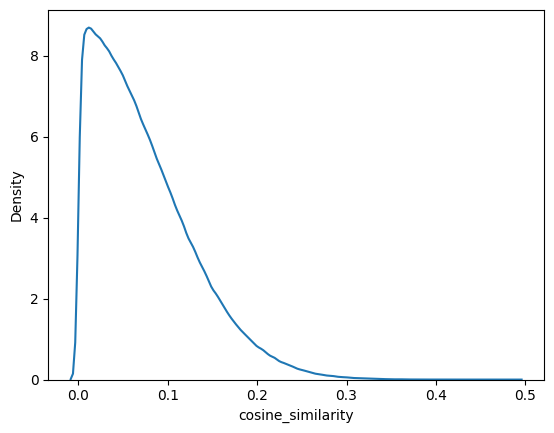

In [ ]:
disease_analogy = analogy_similarity_dataframe[(analogy_similarity_dataframe['cosine_similarity'] != 0) & (np.abs(analogy_similarity_dataframe['cosine_similarity']) < 0.99)]
disease_analogy['cosine_similarity'] = np.abs(disease_analogy['cosine_similarity'])
disease_analogy.drop_duplicates(subset=['disease_a', 'disease_b', 'disease_c', 'disease_d'], inplace=True)
disease_analogy.sort_values('cosine_similarity', ascending=False, inplace=True)
print(disease_analogy.shape)
n = 50
display(disease_analogy.head(50), disease_analogy.tail(50))
sns.kdeplot(disease_analogy['cosine_similarity'])